In [ ]:
# Advanced Analytics + Risk Metrics

## 1. Setup and Data Loading
## 2. Historical VaR and CVaR
## 3. Rolling 90-Day Sharpe Ratio
## 4. Investor Cohort Analysis
## 5. SIP Continuity Analysis
## 6. Fund Recommender
## 7. Sector HHI Concentration
## 8. Advanced Insights


In [ ]:
## 1. Setup and Data Loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

print(os.listdir("../data"))
print(os.listdir("../data/processed"))

data_path = "../data/processed"

nav_history = pd.read_csv(
    os.path.join(data_path, "clean_nav_history.csv")
)

investor_transactions = pd.read_csv(
    os.path.join(data_path, "clean_investor_transactions.csv")
)

portfolio_holdings = pd.read_csv(
    os.path.join(data_path, "clean_portfolio_holdings.csv")
)

scheme_performance = pd.read_csv(
    os.path.join(data_path, "clean_scheme_performance.csv")
)

fund_master = pd.read_csv(
    os.path.join(data_path, "clean_fund_master.csv")
)

print("Datasets loaded successfully.")

print("NAV History:")
print(nav_history.columns.tolist())

print("\nInvestor Transactions:")
print(investor_transactions.columns.tolist())

print("\nPortfolio Holdings:")
print(portfolio_holdings.columns.tolist())

print("\nScheme Performance:")
print(scheme_performance.columns.tolist())

print("\nFund Master:")
print(fund_master.columns.tolist())

['processed', 'raw']
['clean_aum_by_fund_house.csv', 'clean_benchmark_indices.csv', 'clean_category_inflows.csv', 'clean_fund_master.csv', 'clean_industry_folio_count.csv', 'clean_investor_transactions.csv', 'clean_monthly_sip_inflows.csv', 'clean_nav_history.csv', 'clean_portfolio_holdings.csv', 'clean_scheme_performance.csv']
Datasets loaded successfully.
NAV History:
['amfi_code', 'date', 'nav']

Investor Transactions:
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']

Portfolio Holdings:
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']

Scheme Performance:
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdo

In [9]:
## 2. Historical VaR and CVaR
# Prepare NAV data for daily return calculation

nav_history["date"] = pd.to_datetime(nav_history["date"])

nav_history = nav_history.sort_values(
    ["amfi_code", "date"]
).copy()

nav_history["daily_return"] = (
    nav_history
    .groupby("amfi_code")["nav"]
    .pct_change()
)

nav_returns = nav_history.dropna(
    subset=["daily_return"]
).copy()

print("Number of schemes:", nav_returns["amfi_code"].nunique())
print("Number of return observations:", len(nav_returns))

nav_returns.head()

Number of schemes: 40
Number of return observations: 45960


,amfi_code,date,nav,daily_return
5751,100016,2022-01-04,5150971.0,-0.010306
5752,100016,2022-01-05,5217239.0,0.012865
5753,100016,2022-01-06,515788.0,-0.901138
5754,100016,2022-01-07,5151639.0,8.987900
5755,100016,2022-01-10,5107136.0,-0.008639


In [50]:
# load NAV history
nav_df = pd.read_csv(
    "./../data/processed/clean_nav_history.csv"
)

nav_df["date"] = pd.to_datetime(nav_df["date"])

nav_df = nav_df.sort_values(
    ["amfi_code", "date"]
).reset_index(drop=True)

nav_df.head()

# calculate daily returns
nav_df["daily_return"] = (
    nav_df
    .groupby("amfi_code")["nav"]
    .pct_change()
)

nav_df[["amfi_code", "date", "nav", "daily_return"]].head(10)

# check abnormal returns
extreme_returns = nav_df[
    (nav_df["daily_return"] < -0.20) |
    (nav_df["daily_return"] > 0.20)
]

print("Number of extreme return observations:", len(extreme_returns))

extreme_returns[
    ["amfi_code", "date", "nav", "daily_return"]
].head(20)

# Filter Invalid Return Observations
returns_df = nav_df[
    (nav_df["daily_return"] >= -0.20) &
    (nav_df["daily_return"] <= 0.20)
].copy()

print("Original observations:", nav_df["daily_return"].notna().sum())
print("Valid return observations:", returns_df["daily_return"].notna().sum())
print("Removed extreme observations:",
      nav_df["daily_return"].notna().sum() -
      returns_df["daily_return"].notna().sum())

# Check the Cleaned Returns
returns_df["daily_return"].describe()
returns_df[
    ["amfi_code", "date", "daily_return"]
].sort_values("daily_return").head(10)
returns_df[
    ["amfi_code", "date", "daily_return"]
].sort_values("daily_return", ascending=False).head(10)

# Calculate Historical VaR and CVaR
var_results = []

for amfi_code, group in returns_df.groupby("amfi_code"):
    
    returns = group["daily_return"].dropna()
    
    var_95 = returns.quantile(0.05)
    
    cvar_95 = returns[
        returns <= var_95
    ].mean()
    
    var_results.append({
        "amfi_code": amfi_code,
        "VaR_95_pct": var_95 * 100,
        "CVaR_95_pct": cvar_95 * 100
    })

var_cvar_report = pd.DataFrame(var_results)

var_cvar_report.head()

performance_df = pd.read_csv(
    "./../data/processed/clean_scheme_performance.csv"
)

var_cvar_report = var_cvar_report.merge(
    performance_df[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

var_cvar_report = var_cvar_report[
    [
        "amfi_code",
        "scheme_name",
        "VaR_95_pct",
        "CVaR_95_pct"
    ]
]

print("Number of funds:", var_cvar_report["amfi_code"].nunique())
print("Duplicate fund codes:", var_cvar_report["amfi_code"].duplicated().sum())
print("Missing VaR:", var_cvar_report["VaR_95_pct"].isna().sum())
print("Missing CVaR:", var_cvar_report["CVaR_95_pct"].isna().sum())

# Save CSV
var_cvar_report.to_csv(
    "./outputs/var_cvar_report.csv",
    index=False
)

Number of extreme return observations: 8209
Original observations: 45960
Valid return observations: 37751
Removed extreme observations: 8209
Number of funds: 40
Duplicate fund codes: 0
Missing VaR: 0
Missing CVaR: 0


NAV History shape: (46000, 3)
   amfi_code       date        nav
0     100016 2022-01-03  5204608.0
1     100016 2022-01-04  5150971.0
2     100016 2022-01-05  5217239.0
3     100016 2022-01-06   515788.0
4     100016 2022-01-07  5151639.0
   amfi_code       date        nav  daily_return
0     100016 2022-01-03  5204608.0           NaN
1     100016 2022-01-04  5150971.0     -0.010306
2     100016 2022-01-05  5217239.0      0.012865
3     100016 2022-01-06   515788.0     -0.901138
4     100016 2022-01-07  5151639.0      8.987900
5     100016 2022-01-10  5107136.0     -0.008639
6     100016 2022-01-11  5135542.0      0.005562
7     100016 2022-01-12  5123195.0     -0.002404
8     100016 2022-01-13  5102445.0     -0.004050
9     100016 2022-01-14  5143636.0      0.008073
Original observations: 46000
Clean observations: 37751
Removed observations: 8249
count    37751.000000
mean         0.000628
std          0.010310
min         -0.051847
25%         -0.005030
50%          0.000350
75%    

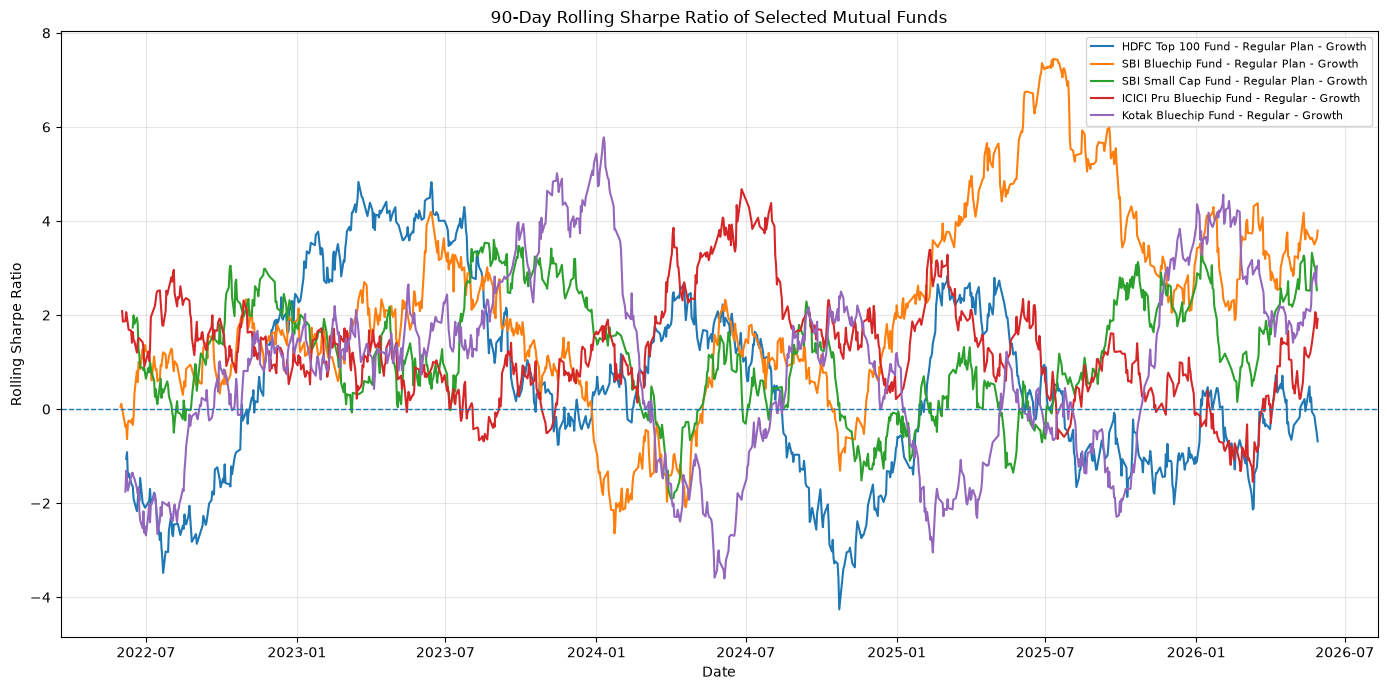

Selected funds: 5
Valid rolling Sharpe observations: 4285

Funds included:
 amfi_code                                scheme_name
    100016  HDFC Top 100 Fund - Regular Plan - Growth
    119551  SBI Bluechip Fund - Regular Plan - Growth
    119598 SBI Small Cap Fund - Regular Plan - Growth
    120503 ICICI Pru Bluechip Fund - Regular - Growth
    120841     Kotak Bluechip Fund - Regular - Growth


<Figure size 640x480 with 0 Axes>

In [ ]:
## 3. Rolling 90-Day Sharpe Ratio
nav_df = pd.read_csv(
    "../data/processed/clean_nav_history.csv"
)

nav_df["date"] = pd.to_datetime(nav_df["date"])

nav_df = nav_df.sort_values(
    ["amfi_code", "date"]
).reset_index(drop=True)

print("NAV History shape:", nav_df.shape)
print(nav_df.head())

# Calculate Daily Returns
nav_df["daily_return"] = (
    nav_df.groupby("amfi_code")["nav"]
    .pct_change()
)

print(nav_df[["amfi_code", "date", "nav", "daily_return"]].head(10))

# Remove Extreme Return Observations
clean_returns = nav_df[
    nav_df["daily_return"].between(-0.20, 0.20)
].copy()

print("Original observations:", len(nav_df))
print("Clean observations:", len(clean_returns))
print(
    "Removed observations:",
    len(nav_df) - len(clean_returns)
)
print(
    clean_returns["daily_return"].describe()
)

print(
    "\nMinimum daily return:",
    clean_returns["daily_return"].min()
)

print(
    "Maximum daily return:",
    clean_returns["daily_return"].max()
)

# Calculate Rolling 90-Day Sharpe
clean_returns = clean_returns.sort_values(
    ["amfi_code", "date"]
).copy()

clean_returns["rolling_mean_90d"] = (
    clean_returns
    .groupby("amfi_code")["daily_return"]
    .transform(
        lambda x: x.rolling(90, min_periods=90).mean()
    )
)

clean_returns["rolling_std_90d"] = (
    clean_returns
    .groupby("amfi_code")["daily_return"]
    .transform(
        lambda x: x.rolling(90, min_periods=90).std()
    )
)

clean_returns["rolling_sharpe_90d"] = (
    clean_returns["rolling_mean_90d"]
    / clean_returns["rolling_std_90d"]
    * np.sqrt(252)
)

print(
    clean_returns[
        [
            "amfi_code",
            "date",
            "daily_return",
            "rolling_mean_90d",
            "rolling_std_90d",
            "rolling_sharpe_90d"
        ]
    ].tail(20)
)

print(
    "\nMissing rolling Sharpe:",
    clean_returns["rolling_sharpe_90d"].isna().sum()
)

print(
    "Number of valid rolling Sharpe:",
    clean_returns["rolling_sharpe_90d"].notna().sum()
)

# Select 5 Key Funds
key_funds = [
    100016,  # HDFC Top 100
    119551,  # SBI Bluechip
    119598,  # SBI Small Cap
    120503,  # ICICI Pru Bluechip
    120841   # Kotak Bluechip
]

rolling_sharpe_5 = clean_returns[
    clean_returns["amfi_code"].isin(key_funds)
].copy()

print(
    rolling_sharpe_5["amfi_code"].unique()
)

# Add Fund Names
performance_df = pd.read_csv(
    "../data/processed/clean_scheme_performance.csv"
)

fund_names = performance_df[
    ["amfi_code", "scheme_name"]
].drop_duplicates()

rolling_sharpe_5 = rolling_sharpe_5.merge(
    fund_names,
    on="amfi_code",
    how="left"
)

print(
    rolling_sharpe_5[
        ["amfi_code", "scheme_name"]
    ].drop_duplicates()
)

# Create Rolling Sharpe Chart
plt.figure(figsize=(14, 7))

for fund_code in key_funds:
    fund_data = rolling_sharpe_5[
        rolling_sharpe_5["amfi_code"] == fund_code
    ].dropna(
        subset=["rolling_sharpe_90d"]
    )

    if not fund_data.empty:
        fund_name = fund_data["scheme_name"].iloc[0]

        plt.plot(
            fund_data["date"],
            fund_data["rolling_sharpe_90d"],
            label=fund_name,
            linewidth=1.5
        )

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.title(
    "90-Day Rolling Sharpe Ratio of Selected Mutual Funds"
)

plt.xlabel("Date")
plt.ylabel("Rolling Sharpe Ratio")

plt.legend(
    loc="best",
    fontsize=8
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

# Save the chart


plt.savefig(
    "./figures/rolling_sharpe_chart.png",
    dpi=300,
    bbox_inches="tight"
)

# Final Validation
print("Selected funds:", len(key_funds))

print(
    "Valid rolling Sharpe observations:",
    rolling_sharpe_5["rolling_sharpe_90d"].notna().sum()
)

print(
    "\nFunds included:"
)

print(
    rolling_sharpe_5[
        ["amfi_code", "scheme_name"]
    ]
    .drop_duplicates()
    .to_string(index=False)
)

In [ ]:
## 4. Investor Cohort Analysis
transactions = pd.read_csv(
    "../data/processed/clean_investor_transactions.csv"
)

transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

transactions.head()

# Identify each investor's first transaction date
first_transaction = (
    transactions
    .groupby("investor_id")["transaction_date"]
    .min()
    .reset_index()
)

first_transaction["cohort_year"] = (
    first_transaction["transaction_date"].dt.year
)

first_transaction.head()

# Add cohort year to the transaction dataset
transactions = transactions.merge(
    first_transaction[
        ["investor_id", "cohort_year"]
    ],
    on="investor_id",
    how="left"
)

transactions.head()

# Number of investors in each cohort
cohort_investors = (
    first_transaction
    .groupby("cohort_year")["investor_id"]
    .nunique()
    .reset_index(name="investor_count")
)

cohort_investors

# Filter SIP transactions
sip_transactions = transactions[
    transactions["transaction_type"].str.upper() == "SIP"
].copy()

sip_transactions.head()

# Average SIP amount by investor cohort
avg_sip = (
    sip_transactions
    .groupby("cohort_year")["amount_inr"]
    .mean()
    .reset_index(name="avg_sip_amount_inr")
)

avg_sip

# Calculate total invested amount
# Investment transactions include SIP and Lumpsum

investment_transactions = transactions[
    transactions["transaction_type"].str.upper().isin(
        ["SIP", "LUMPSUM"]
    )
].copy()

total_invested = (
    investment_transactions
    .groupby("cohort_year")["amount_inr"]
    .sum()
    .reset_index(name="total_invested_inr")
)

total_invested

# Count SIP transactions by cohort and fund
fund_preference = (
    sip_transactions
    .groupby(
        ["cohort_year", "amfi_code"]
    )
    .size()
    .reset_index(name="sip_transaction_count")
)

fund_preference.head()

# Select the most preferred fund for each cohort
top_fund = (
    fund_preference
    .sort_values(
        ["cohort_year", "sip_transaction_count"],
        ascending=[True, False]
    )
    .drop_duplicates("cohort_year")
)

top_fund

# Load fund master data
fund_master = pd.read_csv(
    "../data/processed/clean_fund_master.csv"
)

fund_master = fund_master[
    ["amfi_code", "scheme_name"]
].drop_duplicates("amfi_code")

# Add fund names
top_fund = top_fund.merge(
    fund_master,
    on="amfi_code",
    how="left"
)

top_fund

# Combine all cohort metrics
cohort_analysis = (
    cohort_investors
    .merge(
        avg_sip,
        on="cohort_year",
        how="left"
    )
    .merge(
        total_invested,
        on="cohort_year",
        how="left"
    )
    .merge(
        top_fund[
            [
                "cohort_year",
                "amfi_code",
                "scheme_name",
                "sip_transaction_count"
            ]
        ],
        on="cohort_year",
        how="left"
    )
)

cohort_analysis

# Rename columns for readability
cohort_analysis = cohort_analysis.rename(
    columns={
        "amfi_code": "top_fund_amfi_code",
        "scheme_name": "top_fund",
        "sip_transaction_count": "top_fund_sip_transactions"
    }
)

cohort_analysis

# Sort by cohort year
cohort_analysis = (
    cohort_analysis
    .sort_values("cohort_year")
    .reset_index(drop=True)
)

cohort_analysis
cohort_analysis.style.format({
    "avg_sip_amount_inr": "₹{:,.2f}",
    "total_invested_inr": "₹{:,.2f}"
})

cohort_analysis.to_csv(
    "./outputs/investor_cohort_analysis.csv",
    index=False
)

print("Investor cohort analysis saved successfully.")


Investor cohort analysis saved successfully.


In [92]:
## 5. SIP Continuity Analysis
sip_transactions = transactions[
    transactions["transaction_type"].str.upper() == "SIP"
].copy()

sip_transactions["transaction_date"] = pd.to_datetime(
    sip_transactions["transaction_date"]
)

sip_transactions = sip_transactions.sort_values(
    ["investor_id", "transaction_date"]
)

sip_transactions.head()

# Calculate the gap between consecutive SIP transactions
sip_transactions["gap_days"] = (
    sip_transactions
    .groupby("investor_id")["transaction_date"]
    .diff()
    .dt.days
)

sip_transactions.head(10)

# Identify investors with at least 6 SIP transactions
sip_counts = (
    sip_transactions
    .groupby("investor_id")
    .size()
    .reset_index(name="sip_transaction_count")
)

eligible_investors = sip_counts[
    sip_counts["sip_transaction_count"] >= 6
].copy()

eligible_investors.head()

# Calculate average gap between SIP transactions
sip_continuity = (
    sip_transactions[
        sip_transactions["investor_id"].isin(
            eligible_investors["investor_id"]
        )
    ]
    .groupby("investor_id")
    .agg(
        sip_transaction_count=("transaction_date", "count"),
        avg_gap_days=("gap_days", "mean")
    )
    .reset_index()
)

sip_continuity.head()

# Flag investors with an average SIP gap greater than 35 days
sip_continuity["continuity_status"] = np.where(
    sip_continuity["avg_gap_days"] > 35,
    "at-risk",
    "regular"
)

sip_continuity.head()

# Summary of SIP continuity status
continuity_summary = (
    sip_continuity["continuity_status"]
    .value_counts()
    .reset_index()
)

continuity_summary.columns = [
    "continuity_status",
    "investor_count"
]

continuity_summary

# Calculate SIP continuity rate
total_eligible = len(sip_continuity)

regular_investors = (
    sip_continuity["continuity_status"] == "regular"
).sum()

continuity_rate = (
    regular_investors / total_eligible * 100
)

print(f"Eligible investors: {total_eligible}")
print(f"Regular SIP investors: {regular_investors}")
print(f"SIP continuity rate: {continuity_rate:.2f}%")

# Save SIP continuity analysis
sip_continuity.to_csv(
    "./outputs/sip_continuity_analysis.csv",
    index=False
)

print("SIP continuity analysis saved successfully.")

Eligible investors: 1362
Regular SIP investors: 30
SIP continuity rate: 2.20%
SIP continuity analysis saved successfully.


In [104]:
def recommend_funds(risk_appetite):
    risk_appetite = risk_appetite.strip().title()
    
    valid_risk = ["Low", "Moderate", "High"]
    
    if risk_appetite not in valid_risk:
        print("Risk appetite harus salah satu dari: Low, Moderate, atau High.")
        return None
    
    recommendations = (
        recommender_data[
            recommender_data["risk_grade"] == risk_appetite
        ]
        .sort_values("sharpe_ratio", ascending=False)
        .head(3)
        .copy()
    )
    
    recommendations = recommendations[
        [
            "amfi_code",
            "scheme_name",
            "risk_grade",
            "sharpe_ratio"
        ]
    ]
    
    return recommendations

In [112]:
## 7. Sector HHI Concentration

project_root = Path.cwd().parent

holdings_path = (
    project_root
    / "data"
    / "processed"
    / "clean_portfolio_holdings.csv"
)

# Check that the file exists
if not holdings_path.exists():
    raise FileNotFoundError(
        f"Portfolio holdings file not found: {holdings_path}"
    )

# Load portfolio holdings
holdings = pd.read_csv(holdings_path)

# Check required columns
required_columns = [
    "amfi_code",
    "sector",
    "weight_pct"
]

missing_columns = [
    col for col in required_columns
    if col not in holdings.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

print("Portfolio holdings loaded successfully.")
print(f"Number of rows: {len(holdings):,}")
print(f"Number of funds: {holdings['amfi_code'].nunique():,}")
print(f"Number of sectors: {holdings['sector'].nunique():,}")

print("\nColumns:")
print(holdings.columns.tolist())

print("\nFirst 5 rows:")
display(holdings.head())

# Calculate sector concentration using HHI
holdings_hhi = holdings.copy()

# Convert sector weights from percentage to proportion
holdings_hhi["sector_weight"] = holdings_hhi["weight_pct"] / 100

# Calculate HHI for each fund
sector_hhi = (
    holdings_hhi
    .groupby(["amfi_code", "sector"], as_index=False)["sector_weight"]
    .sum()
)

sector_hhi["sector_weight_squared"] = (
    sector_hhi["sector_weight"] ** 2
)

hhi_by_fund = (
    sector_hhi
    .groupby("amfi_code", as_index=False)["sector_weight_squared"]
    .sum()
    .rename(columns={"sector_weight_squared": "sector_hhi"})
)

print("Sector HHI calculation completed.")
print(f"Number of funds: {hhi_by_fund['amfi_code'].nunique():,}")

display(hhi_by_fund.head(10))

Portfolio holdings loaded successfully.
Number of rows: 322
Number of funds: 34
Number of sectors: 14

Columns:
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']

First 5 rows:


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


Sector HHI calculation completed.
Number of funds: 34


,amfi_code,sector_hhi
0,100016,0.180588
1,100033,0.227647
2,101206,0.180042
3,101207,0.222727
4,102885,0.180712
5,102886,0.124020
6,102887,0.251383
7,118632,0.207259
8,118633,0.221200
9,118634,0.160299


In [119]:
print("HHI summary:")
print(hhi_by_fund["sector_hhi"].describe())

print("\nMinimum HHI:")
print(hhi_by_fund["sector_hhi"].min())

print("\nMaximum HHI:")
print(hhi_by_fund["sector_hhi"].max())

# Load fund master data
fund_master_path = (
    project_root
    / "data"
    / "processed"
    / "clean_fund_master.csv"
)

fund_master = pd.read_csv(fund_master_path)

print(fund_master.columns.tolist())

# Load fund master data
fund_master_path = (
    project_root
    / "data"
    / "processed"
    / "clean_fund_master.csv"
)

fund_master = pd.read_csv(fund_master_path)

print("Fund master columns:")
print(fund_master.columns.tolist())

print("\nPreview:")
display(fund_master.head())

HHI summary:
count    34.000000
mean      0.202929
std       0.038622
min       0.124020
25%       0.180179
50%       0.204254
75%       0.230510
max       0.296769
Name: sector_hhi, dtype: float64

Minimum HHI:
0.12402024

Maximum HHI:
0.29676909
['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']
Fund master columns:
['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']

Preview:


,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [ ]:
# Calculate final Sector HHI for each fund
hhi_by_fund = (
    sector_hhi
    .groupby("amfi_code", as_index=False)["sector_weight_squared"]
    .sum()
    .rename(columns={"sector_weight_squared": "sector_hhi"})
)

print("Sector HHI per fund calculated successfully.")

print("\nNumber of funds:", hhi_by_fund["amfi_code"].nunique())
print("Missing HHI:", hhi_by_fund["sector_hhi"].isna().sum())

print("\nHHI summary:")
print(hhi_by_fund["sector_hhi"].describe())

display(hhi_by_fund.head(10))

# Merge HHI results with fund master information

hhi_with_names = hhi_by_fund.merge(
    fund_master[
        [
            "amfi_code",
            "scheme_name",
            "category",
            "sub_category",
            "plan"
        ]
    ],
    on="amfi_code",
    how="left"
)

# Reorder columns
hhi_with_names = hhi_with_names[
    [
        "amfi_code",
        "scheme_name",
        "category",
        "sub_category",
        "plan",
        "sector_hhi"
    ]
]

print("HHI results with fund names:")
display(hhi_with_names.head(10))

print("\nNumber of funds:", len(hhi_with_names))
print(
    "Missing scheme names:",
    hhi_with_names["scheme_name"].isna().sum()
)
print(
    "Missing HHI:",
    hhi_with_names["sector_hhi"].isna().sum()
)

# Save Sector HHI concentration analysis
output_path = (
    project_root
    / "data"
    / "processed"
    / "sector_hhi_concentration.csv"
)

hhi_with_names.to_csv(
    output_path,
    index=False
)

print("Sector HHI concentration analysis saved successfully.")
print(f"Output file: {output_path}")

Sector HHI per fund calculated successfully.

Number of funds: 34
Missing HHI: 0

HHI summary:
count    34.000000
mean      0.202929
std       0.038622
min       0.124020
25%       0.180179
50%       0.204254
75%       0.230510
max       0.296769
Name: sector_hhi, dtype: float64


,amfi_code,sector_hhi
0,100016,0.180588
1,100033,0.227647
2,101206,0.180042
3,101207,0.222727
4,102885,0.180712
5,102886,0.124020
6,102887,0.251383
7,118632,0.207259
8,118633,0.221200
9,118634,0.160299


HHI results with fund names:


,amfi_code,scheme_name,category,sub_category,plan,sector_hhi
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,Equity,Large Cap,Regular,0.180588
1,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,Mid Cap,Regular,0.227647
2,101206,ABSL Frontline Equity Fund - Regular - Growth,Equity,Large Cap,Regular,0.180042
3,101207,ABSL Small Cap Fund - Regular - Growth,Equity,Small Cap,Regular,0.222727
4,102885,UTI Nifty 50 Index Fund - Regular - Growth,Equity,Index,Regular,0.180712
5,102886,UTI Mid Cap Fund - Regular - Growth,Equity,Mid Cap,Regular,0.124020
6,102887,UTI Flexi Cap Fund - Regular - Growth,Equity,Flexi Cap,Regular,0.251383
7,118632,Nippon India Large Cap Fund - Regular - Growth,Equity,Large Cap,Regular,0.207259
8,118633,Nippon India Large Cap Fund - Direct - Growth,Equity,Large Cap,Direct,0.221200
9,118634,Nippon India Small Cap Fund - Regular - Growth,Equity,Small Cap,Regular,0.160299



Number of funds: 34
Missing scheme names: 0
Missing HHI: 0
Sector HHI concentration analysis saved successfully.
Output file: c:\Users\Zalsabilah.R.A.Arep\OneDrive\Documents\internship\bluestock-mf-capstone\data\processed\sector_hhi_concentration.csv


In [129]:
from pathlib import Path
import pandas as pd

cohort_path = Path.cwd() / "outputs" / "investor_cohort_analysis.csv"

print("File exists:", cohort_path.exists())

cohort_check = pd.read_csv(cohort_path)

print("Rows:", len(cohort_check))
print("Columns:", cohort_check.columns.tolist())

display(cohort_check.head(10))

File exists: True
Rows: 2
Columns: ['cohort_year', 'investor_count', 'avg_sip_amount_inr', 'total_invested_inr', 'top_fund_amfi_code', 'top_fund', 'top_fund_sip_transactions']


,cohort_year,investor_count,avg_sip_amount_inr,total_invested_inr,top_fund_amfi_code,top_fund,top_fund_sip_transactions
0,2024,4803,10996.885825,2258062304,120504,ICICI Pru Bluechip Fund - Direct - Growth,536
1,2025,197,13505.209581,18992635,119599,SBI Small Cap Fund - Direct Plan - Growth,8


# D6 — Advanced Analytics

This notebook contains the advanced analytics required for the Bluestock Mutual Fund Capstone project.

## Analyses Completed

### 1. VaR and CVaR Analysis
Value at Risk (VaR) and Conditional Value at Risk (CVaR) were calculated to evaluate downside risk across mutual fund schemes.

### 2. Rolling Sharpe Ratio Analysis
Rolling Sharpe Ratio was calculated to evaluate changes in risk-adjusted performance over time.

**Output:**
- Rolling Sharpe Ratio visualization saved in `analysis/figures/`.

### 3. SIP Continuity Analysis
Investor SIP transaction history was analyzed to identify regular SIP investors and investors who may be at risk of discontinuing their SIP activity.

**Output:**
- `analysis/outputs/sip_continuity_analysis.csv`

### 4. Investor Cohort Analysis
Investors were grouped by cohort year to analyze investor count, average SIP amount, total invested amount, and the most frequently used fund.

**Output:**
- `analysis/outputs/investor_cohort_analysis.csv`

### 5. Fund Recommendation
A rule-based mutual fund recommender was developed using investor risk appetite, fund risk grade, and Sharpe Ratio.

**Implementation:**
- `scripts/recommender.py`

### 6. Sector HHI Concentration Analysis
Sector concentration was measured using the Herfindahl-Hirschman Index (HHI) based on portfolio sector weights.

**Output:**
- Sector HHI results saved in `data/processed/`.

## D6 Summary

The completed advanced analytics cover:

- downside risk through VaR and CVaR,
- risk-adjusted performance through Rolling Sharpe Ratio,
- SIP continuity,
- investor cohort behavior,
- risk-based fund recommendations, and
- sector concentration using HHI.

In [ ]:
project_root = Path.cwd().parent

d6_outputs = {
    "SIP Continuity": project_root / "analysis" / "outputs" / "sip_continuity_analysis.csv",
    "Investor Cohort": project_root / "analysis" / "outputs" / "investor_cohort_analysis.csv",
    "Rolling Sharpe Figure": project_root / "analysis" / "figures" / "rolling_sharpe_chart.png",
    "Sector HHI": project_root / "data" / "processed" / "sector_hhi_concentration.csv",
    "Fund Recommender": project_root / "scripts" / "recommender.py",
}

print("=== D6 OUTPUT CHECK ===")

for name, path in d6_outputs.items():
    if path.exists():
        print(f"OK       | {name:<25} | {path}")
    else:
        print(f"MISSING  | {name:<25} | {path}")

=== D6 OUTPUT CHECK ===
OK       | SIP Continuity            | c:\Users\Zalsabilah.R.A.Arep\OneDrive\Documents\internship\bluestock-mf-capstone\analysis\outputs\sip_continuity_analysis.csv
OK       | Investor Cohort           | c:\Users\Zalsabilah.R.A.Arep\OneDrive\Documents\internship\bluestock-mf-capstone\analysis\outputs\investor_cohort_analysis.csv
OK       | Rolling Sharpe Figure     | c:\Users\Zalsabilah.R.A.Arep\OneDrive\Documents\internship\bluestock-mf-capstone\analysis\figures\rolling_sharpe_chart.png
OK       | Sector HHI                | c:\Users\Zalsabilah.R.A.Arep\OneDrive\Documents\internship\bluestock-mf-capstone\data\processed\sector_hhi_concentration.csv
OK       | Fund Recommender          | c:\Users\Zalsabilah.R.A.Arep\OneDrive\Documents\internship\bluestock-mf-capstone\scripts\recommender.py


In [132]:
#8 Insight
project_root = Path.cwd().parent

performance_path = (
    project_root
    / "data"
    / "processed"
    / "clean_scheme_performance.csv"
)

performance = pd.read_csv(performance_path)

hhi_path = (
    project_root
    / "data"
    / "processed"
    / "sector_hhi_concentration.csv"
)

sector_hhi = pd.read_csv(hhi_path)

print("=== ADVANCED INSIGHTS DATA CHECK ===")

print("Performance rows:", len(performance))
print("Performance columns:", performance.columns.tolist())

print("HHI rows:", len(sector_hhi))
print("HHI columns:", sector_hhi.columns.tolist())

print(
    "Missing Sharpe Ratio:",
    performance["sharpe_ratio"].isna().sum()
)

print(
    "Missing Risk Grade:",
    performance["risk_grade"].isna().sum()
)

print(
    "Missing HHI:",
    sector_hhi["sector_hhi"].isna().sum()
)

=== ADVANCED INSIGHTS DATA CHECK ===
Performance rows: 40
Performance columns: ['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']
HHI rows: 34
HHI columns: ['amfi_code', 'scheme_name', 'category', 'sub_category', 'plan', 'sector_hhi']
Missing Sharpe Ratio: 0
Missing Risk Grade: 0
Missing HHI: 0


In [133]:
# ============================================================
# 8.1 RISK PROFILE SUMMARY
# ============================================================

risk_summary = (
    performance["risk_grade"]
    .value_counts()
    .rename_axis("risk_grade")
    .reset_index(name="fund_count")
)

risk_summary["percentage"] = (
    risk_summary["fund_count"]
    / risk_summary["fund_count"].sum()
    * 100
)

print("=== RISK PROFILE SUMMARY ===")
display(risk_summary)

print("\nTotal funds:", risk_summary["fund_count"].sum())

=== RISK PROFILE SUMMARY ===


,risk_grade,fund_count,percentage
0,Moderate,16,40.0
1,High,8,20.0
2,Very High,6,15.0
3,Low,6,15.0
4,Moderately High,4,10.0



Total funds: 40


In [134]:
# ============================================================
# 8.2 RISK-ADJUSTED PERFORMANCE INSIGHT
# ============================================================

sharpe_by_risk = (
    performance
    .groupby("risk_grade", as_index=False)
    .agg(
        fund_count=("amfi_code", "count"),
        avg_sharpe_ratio=("sharpe_ratio", "mean"),
        min_sharpe_ratio=("sharpe_ratio", "min"),
        max_sharpe_ratio=("sharpe_ratio", "max")
    )
    .sort_values("avg_sharpe_ratio", ascending=False)
)

print("=== SHARPE RATIO BY RISK GRADE ===")
display(sharpe_by_risk)

print("\nHighest average Sharpe Ratio:")
display(sharpe_by_risk.head(1))

print("\nLowest average Sharpe Ratio:")
display(sharpe_by_risk.tail(1))

=== SHARPE RATIO BY RISK GRADE ===


,risk_grade,fund_count,avg_sharpe_ratio,min_sharpe_ratio,max_sharpe_ratio
1,Low,6,3.948333,1.33,7.68
3,Moderately High,4,0.957500,0.91,0.98
2,Moderate,16,0.926875,0.81,1.06
4,Very High,6,0.870000,0.80,0.94
0,High,8,0.862500,0.80,0.96



Highest average Sharpe Ratio:


,risk_grade,fund_count,avg_sharpe_ratio,min_sharpe_ratio,max_sharpe_ratio
1,Low,6,3.948333,1.33,7.68



Lowest average Sharpe Ratio:


,risk_grade,fund_count,avg_sharpe_ratio,min_sharpe_ratio,max_sharpe_ratio
0,High,8,0.8625,0.8,0.96


In [135]:
# ============================================================
# 8.3 PORTFOLIO CONCENTRATION INSIGHT
# ============================================================

hhi_summary = (
    sector_hhi
    .groupby("category", as_index=False)
    .agg(
        fund_count=("amfi_code", "count"),
        avg_sector_hhi=("sector_hhi", "mean"),
        min_sector_hhi=("sector_hhi", "min"),
        max_sector_hhi=("sector_hhi", "max")
    )
    .sort_values("avg_sector_hhi", ascending=False)
)

print("=== SECTOR HHI BY CATEGORY ===")
display(hhi_summary)

print("\nOverall HHI statistics:")
print(sector_hhi["sector_hhi"].describe())

print("\nMost concentrated fund:")
display(
    sector_hhi.nlargest(
        5,
        "sector_hhi"
    )[
        [
            "amfi_code",
            "scheme_name",
            "category",
            "sub_category",
            "sector_hhi"
        ]
    ]
)

print("\nLeast concentrated fund:")
display(
    sector_hhi.nsmallest(
        5,
        "sector_hhi"
    )[
        [
            "amfi_code",
            "scheme_name",
            "category",
            "sub_category",
            "sector_hhi"
        ]
    ]
)

=== SECTOR HHI BY CATEGORY ===


,category,fund_count,avg_sector_hhi,min_sector_hhi,max_sector_hhi
0,Equity,34,0.202929,0.12402,0.296769



Overall HHI statistics:
count    34.000000
mean      0.202929
std       0.038622
min       0.124020
25%       0.180179
50%       0.204254
75%       0.230510
max       0.296769
Name: sector_hhi, dtype: float64

Most concentrated fund:


,amfi_code,scheme_name,category,sub_category,sector_hhi
11,119092,Axis Bluechip Fund - Regular - Growth,Equity,Large Cap,0.296769
30,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Equity,ELSS,0.254992
27,125498,HDFC Mid-Cap Opportunities Fund - Direct - Growth,Equity,Mid Cap,0.253155
6,102887,UTI Flexi Cap Fund - Regular - Growth,Equity,Flexi Cap,0.251383
32,149323,DSP Midcap Fund - Regular - Growth,Equity,Mid Cap,0.241077



Least concentrated fund:


,amfi_code,scheme_name,category,sub_category,sector_hhi
5,102886,UTI Mid Cap Fund - Regular - Growth,Equity,Mid Cap,0.124020
25,120843,Kotak Flexicap Fund - Regular - Growth,Equity,Flexi Cap,0.136206
15,119551,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,0.142491
14,119095,Axis Small Cap Fund - Regular - Growth,Equity,Small Cap,0.159582
9,118634,Nippon India Small Cap Fund - Regular - Growth,Equity,Small Cap,0.160299


In [136]:
# ============================================================
# 8.4 INVESTOR BEHAVIOR INSIGHT
# ============================================================

sip_path = (
    project_root
    / "analysis"
    / "outputs"
    / "sip_continuity_analysis.csv"
)

cohort_path = (
    project_root
    / "analysis"
    / "outputs"
    / "investor_cohort_analysis.csv"
)

sip_continuity = pd.read_csv(sip_path)
investor_cohort = pd.read_csv(cohort_path)

print("=== SIP CONTINUITY SUMMARY ===")

continuity_summary = (
    sip_continuity["continuity_status"]
    .value_counts()
    .rename_axis("continuity_status")
    .reset_index(name="investor_count")
)

continuity_summary["percentage"] = (
    continuity_summary["investor_count"]
    / continuity_summary["investor_count"].sum()
    * 100
)

display(continuity_summary)

print("\n=== INVESTOR COHORT ANALYSIS ===")

display(investor_cohort)

print("\nSIP continuity investors:", len(sip_continuity))
print("Cohort groups:", len(investor_cohort))

=== SIP CONTINUITY SUMMARY ===


,continuity_status,investor_count,percentage
0,at-risk,1332,97.797357
1,regular,30,2.202643



=== INVESTOR COHORT ANALYSIS ===


,cohort_year,investor_count,avg_sip_amount_inr,total_invested_inr,top_fund_amfi_code,top_fund,top_fund_sip_transactions
0,2024,4803,10996.885825,2258062304,120504,ICICI Pru Bluechip Fund - Direct - Growth,536
1,2025,197,13505.209581,18992635,119599,SBI Small Cap Fund - Direct Plan - Growth,8



SIP continuity investors: 1362
Cohort groups: 2


In [137]:
# ============================================================
# 8.5 COMBINED ADVANCED INSIGHTS
# ============================================================

print("=== COMBINED ADVANCED INSIGHTS ===")

# ------------------------------------------------------------
# 1. Risk profile
# ------------------------------------------------------------

dominant_risk = risk_summary.iloc[0]

print(
    f"1. Risk Profile: {dominant_risk['risk_grade']} "
    f"is the largest risk group with "
    f"{int(dominant_risk['fund_count'])} funds "
    f"({dominant_risk['percentage']:.1f}%)."
)

# ------------------------------------------------------------
# 2. Risk-adjusted performance
# ------------------------------------------------------------

highest_sharpe_group = sharpe_by_risk.iloc[0]

print(
    f"2. Risk-Adjusted Performance: The "
    f"{highest_sharpe_group['risk_grade']} risk group has the "
    f"highest average Sharpe Ratio at "
    f"{highest_sharpe_group['avg_sharpe_ratio']:.2f}."
)

# ------------------------------------------------------------
# 3. Sector concentration
# ------------------------------------------------------------

highest_hhi_fund = sector_hhi.loc[
    sector_hhi["sector_hhi"].idxmax()
]

lowest_hhi_fund = sector_hhi.loc[
    sector_hhi["sector_hhi"].idxmin()
]

print(
    f"3. Sector Concentration: "
    f"{highest_hhi_fund['scheme_name']} has the highest "
    f"sector HHI at {highest_hhi_fund['sector_hhi']:.4f}, "
    f"while {lowest_hhi_fund['scheme_name']} has the lowest "
    f"at {lowest_hhi_fund['sector_hhi']:.4f}."
)

# ------------------------------------------------------------
# 4. SIP continuity
# ------------------------------------------------------------

regular_sip = continuity_summary.loc[
    continuity_summary["continuity_status"] == "regular",
    "percentage"
].iloc[0]

at_risk_sip = continuity_summary.loc[
    continuity_summary["continuity_status"] == "at-risk",
    "percentage"
].iloc[0]

print(
    f"4. SIP Continuity: {regular_sip:.2f}% of eligible investors "
    f"are classified as regular SIP investors, while "
    f"{at_risk_sip:.2f}% are classified as at-risk."
)

# ------------------------------------------------------------
# 5. Cohort comparison
# ------------------------------------------------------------

if len(investor_cohort) >= 2:

    cohort_2024 = investor_cohort[
        investor_cohort["cohort_year"] == 2024
    ]

    cohort_2025 = investor_cohort[
        investor_cohort["cohort_year"] == 2025
    ]

    if not cohort_2024.empty and not cohort_2025.empty:

        avg_sip_2024 = cohort_2024["avg_sip_amount_inr"].iloc[0]
        avg_sip_2025 = cohort_2025["avg_sip_amount_inr"].iloc[0]

        print(
            f"5. Investor Cohort: The 2025 cohort has a higher "
            f"average SIP amount (INR {avg_sip_2025:,.2f}) "
            f"than the 2024 cohort "
            f"(INR {avg_sip_2024:,.2f})."
        )

=== COMBINED ADVANCED INSIGHTS ===
1. Risk Profile: Moderate is the largest risk group with 16 funds (40.0%).
2. Risk-Adjusted Performance: The Low risk group has the highest average Sharpe Ratio at 3.95.
3. Sector Concentration: Axis Bluechip Fund - Regular - Growth has the highest sector HHI at 0.2968, while UTI Mid Cap Fund - Regular - Growth has the lowest at 0.1240.
4. SIP Continuity: 2.20% of eligible investors are classified as regular SIP investors, while 97.80% are classified as at-risk.
5. Investor Cohort: The 2025 cohort has a higher average SIP amount (INR 13,505.21) than the 2024 cohort (INR 10,996.89).


## 8.6 Final Advanced Analytics Summary
The advanced analytics analysis provides several key insights across fund risk, risk-adjusted performance, portfolio concentration, and investor behavior.

### 1. Risk Profile
The dataset contains 40 mutual funds, with **Moderate** risk funds representing the largest group at **16 funds (40.0%)**. The remaining funds are distributed across High, Very High, Low, and Moderately High risk grades.

### 2. Risk-Adjusted Performance
The **Low** risk group has the highest average Sharpe Ratio at **3.95**. However, this result should be interpreted carefully because the Low-risk group has a relatively wide Sharpe Ratio range, from **1.33 to 7.68**. Therefore, the higher average is not sufficient to conclude that Low-risk funds universally provide better risk-adjusted performance.

### 3. Sector Concentration
Sector HHI was calculated for **34 equity funds**. The HHI values range from **0.1240 to 0.2968**, with an average of approximately **0.2029**. The highest sector concentration is observed in **Axis Bluechip Fund - Regular - Growth** with an HHI of **0.2968**, while **UTI Mid Cap Fund - Regular - Growth** has the lowest HHI at **0.1240**.

### 4. SIP Continuity
The SIP continuity analysis identified **1,362 eligible investors**. Only **30 investors (2.20%)** were classified as regular SIP investors, while **1,332 investors (97.80%)** were classified as at-risk based on the continuity criteria used in the analysis.

### 5. Investor Cohort Analysis
The investor cohort analysis shows that the **2025 cohort** has a higher average SIP amount of approximately **INR 13,505.21**, compared with **INR 10,996.89** for the 2024 cohort. The 2024 cohort contains substantially more investors and a larger total invested amount than the 2025 cohort.

### Overall Insight
The analysis highlights that mutual fund evaluation should consider multiple dimensions rather than relying on a single metric. Risk grade, Sharpe Ratio, sector concentration, SIP continuity, and investor cohort behavior provide complementary perspectives for evaluating fund characteristics and investor behavior. These results can support further portfolio analysis, investor segmentation, and fund recommendation decisions.